# Nuisance parameters via the **training-time augmentation** path

The companion notebook [`nuisance_parameters_demo.ipynb`](nuisance_parameters_demo.ipynb)
shows nuisance effects applied inside the **simulator** (`Simulator.run_simulation`).

This notebook shows the other route: Category-2 nuisances applied **during ML training, as
per-batch augmentation of a fixed set of clean simulations saved to disk**. The steps are those
of `TorchSimulationDataset.__getitem__`:

1. Run **one** clean (noise- and nuisance-free) simulation and **save it to disk** as h5.
2. Load it back as a stacked array `D` of shape `(n_stations, n_components, T)`.
3. Apply a `PostProcessingChain` of nuisance effects to `D` with `apply_chain_to_array`, using
   the same effect classes as at simulation time.
4. Build the chain from a configuration-style nuisance dict with `build_augmentation_chain`,
   which honours each nuisance's `stage` key.
5. Run the full `TorchSimulationDataset` augmentation path end to end.

---
**Requirements**: set `INSTASEIS_DB` to a local Instaseis database, or leave it unset to use
the `syngine://prem_i_2s` online service.

In [1]:
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.receivers import Receiver, Receivers
from seismo_sbi.simulators.simulation_io import SimulationDataLoader
from seismo_sbi.nuisance_effects.post_processing import (
    PostProcessingChain,
    apply_chain_to_array,
    build_augmentation_chain,
)
from seismo_sbi.nuisance_effects.amplitude_effect import AmplitudeErrorEffect
from seismo_sbi.nuisance_effects.dropout_effects import InstrumentDropoutEffect
from seismo_sbi.nuisance_effects.time_shift_effect import TimeShiftErrorEffect
from seismo_sbi.nuisance_effects.scattering_coda_effect import ScatteringCodaEffect

# ── Configuration ──────────────────────────────────────────────────────────────
INSTASEIS_DB  = os.environ.get("INSTASEIS_DB", "syngine://prem_i_2s")
SAMPLING_RATE = 1.0     # Hz
DURATION      = 200     # seconds
COMPONENTS    = ["Z", "N", "E"]
PROCESSING = {
    "filter": {"type": "bandpass", "freqmin": 0.02, "freqmax": 0.1,
               "corners": 4, "zerophase": False},
    "sampling_rate": SAMPLING_RATE,
    "filter_sampling_rate": 5.0,
}

# ── Source: Long Valley, Mw 7.3 ────────────────────────────────────────────────
SOURCE_LOC    = [37.636, -118.936, 10.0, 0.0]
MOMENT_TENSOR = [0.0, 1e20, -1e20, 0.0, 0.0, 0.0]
BASE_PARAMS   = {"source_location": SOURCE_LOC, "moment_tensor": MOMENT_TENSOR}

# ── Stations ───────────────────────────────────────────────────────────────────
_station_data = [
    ("STA1", 39.2, -118.9),   # N
    ("STA2", 39.0, -121.0),   # NW
    ("STA3", 39.0, -116.0),   # NE
    ("STA4", 35.5, -116.0),   # SE
    ("STA5", 34.8, -120.5),   # S
]
receivers = Receivers(receivers=[
    Receiver(latitude=lat, longitude=lon, station_name=name, components=COMPONENTS)
    for name, lat, lon in _station_data
])
station_names = [name for name, _, _ in _station_data]
print(f"Instaseis DB: {INSTASEIS_DB}")
print(f"{len(station_names)} stations, components {COMPONENTS}")

At receiver init [0, 0, 0, 0, 0]
Instaseis DB: syngine://prem_i_2s
5 stations, components ['Z', 'N', 'E']


## 1. Run one clean simulation and save it to disk

This is the "fixed, well-defined, noise- and nuisance-free simulation" we want to augment.
We build the simulator with **no** post-processing effects, run it once, and dump it to an
h5 file using the same `SimulationSaver` schema the training pipeline uses.

In [2]:
base_sim = InstaseisSourceSimulator(
    instaseis_model_loc=INSTASEIS_DB,
    components=COMPONENTS,
    receivers=receivers,
    seismogram_duration_in_s=DURATION,
    synthetics_processing=PROCESSING,
)

sim_dir = tempfile.mkdtemp(prefix="aug_demo_")
sim_path = os.path.join(sim_dir, "clean_sim_0.h5")

print("Running + saving one clean simulation ...", end="", flush=True)
base_sim.execute_sim_and_save_outputs(BASE_PARAMS, sim_path)
print(" done")
print("Saved to:", sim_path)
print("On-disk size:", f"{os.path.getsize(sim_path)/1e3:.0f} kB")

Running + saving one clean simulation ... done
Saved to: /tmp/aug_demo_1g6w8mmi/clean_sim_0.h5
On-disk size: 39 kB


## 2. Load it back as a stacked array `D`

`SimulationDataLoader.load_simulation_data_array(..., stacked=True, fill_unused=True)`
returns the array the dataloader feeds the network: shape `(n_stations, n_components, T)`,
component axis ordered by the loader's `components`, unused components zero-filled.

D_clean shape (n_stations, n_components, T): (5, 3, 201)
Empty-chain round-trip identical to D_clean: True


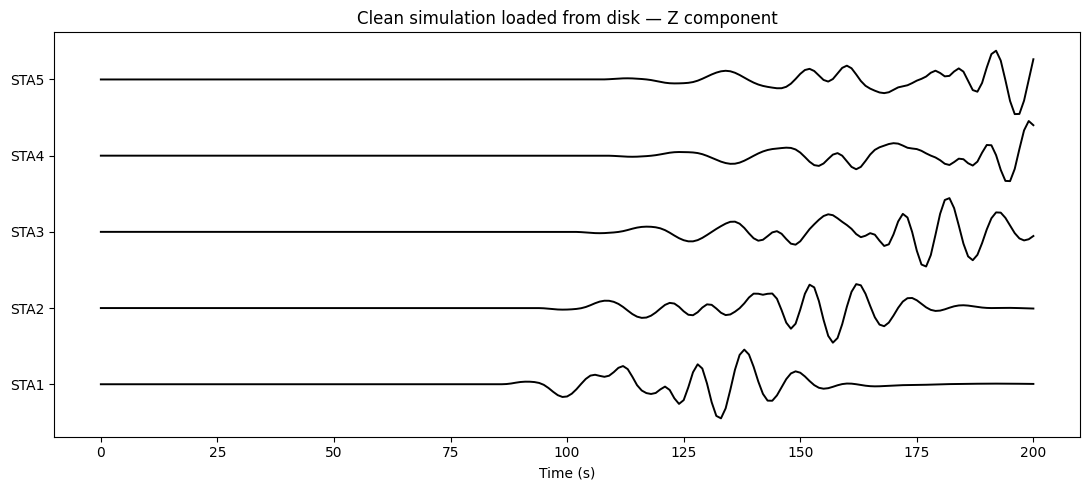

In [3]:
data_loader = SimulationDataLoader(components=COMPONENTS, receivers=receivers)
D_clean = data_loader.load_simulation_data_array(sim_path, stacked=True, fill_unused=True)

n_stations, n_components, trace_len = D_clean.shape
t_axis = np.arange(trace_len) / SAMPLING_RATE
print("D_clean shape (n_stations, n_components, T):", D_clean.shape)

# ── Plot helper: per-station Z traces, clean (black) vs augmented (colour) ──────
Z = COMPONENTS.index("Z")

def plot_overlay(D_clean, D_aug, title, aug_label="augmented", aug_color="crimson",
                 comp=Z, ax=None):
    # Overlay clean vs one augmented realisation, one row per station.
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 5))
    offset = 2.2
    for i, name in enumerate(station_names):
        c = D_clean[i, comp]
        a = D_aug[i, comp]
        norm = np.max(np.abs(c)) or 1.0
        ax.plot(t_axis, c / norm + i * offset, "k-", lw=1.6, zorder=3)
        ax.plot(t_axis, a / norm + i * offset, color=aug_color, lw=1.0, alpha=0.9, zorder=2)
    ax.set_yticks([i * offset for i in range(n_stations)])
    ax.set_yticklabels(station_names)
    ax.set_xlabel("Time (s)")
    ax.set_title(title)
    ax.legend(handles=[
        Line2D([0], [0], color="k", lw=1.6, label="clean (from disk)"),
        Line2D([0], [0], color=aug_color, lw=1.2, label=aug_label),
    ], loc="upper right", fontsize=8)
    return ax

# Sanity check: empty chain must round-trip D exactly (lossless adapter).
D_roundtrip = apply_chain_to_array(PostProcessingChain([]), D_clean, receivers, COMPONENTS, {})
print("Empty-chain round-trip identical to D_clean:", np.array_equal(D_roundtrip, D_clean))

fig, ax = plt.subplots(figsize=(11, 5))
for i, name in enumerate(station_names):
    c = D_clean[i, Z]
    ax.plot(t_axis, c / (np.max(np.abs(c)) or 1.0) + i * 2.2, "k-", lw=1.4)
ax.set_yticks([i * 2.2 for i in range(n_stations)]); ax.set_yticklabels(station_names)
ax.set_xlabel("Time (s)"); ax.set_title("Clean simulation loaded from disk — Z component")
plt.tight_layout(); plt.show()

## 3. Augment `D` with each effect, one at a time

We apply each effect through `apply_chain_to_array(chain, D, receivers, components, nuisance_params)`.
The `nuisance_params` dict activates the effect (e.g. `{"amplitude_error": 1.0}`) exactly as a
sampled nuisance value would in the pipeline.  Note that for `amplitude_error`,
`instrument_dropout` and `scattering_coda` the scalar is a **per-station probability**.

### 3a. Amplitude error — per-station random rescaling

  STA1: amplitude x1.91
  STA2: amplitude x1.03
  STA3: amplitude x0.59
  STA4: amplitude x1.13
  STA5: amplitude x1.53


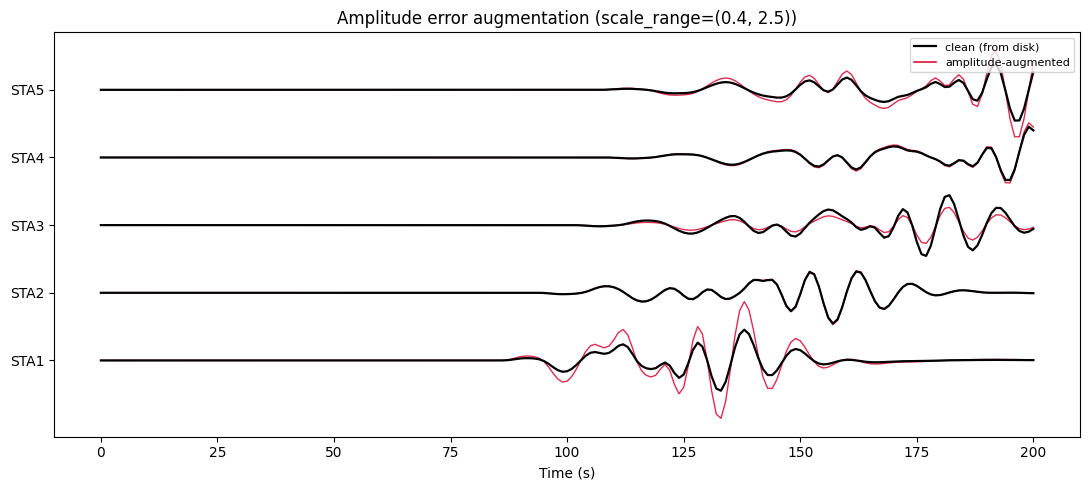

In [4]:
np.random.seed(1)
amp_chain = PostProcessingChain([AmplitudeErrorEffect(scale_range=(0.4, 2.5))])
D_amp = apply_chain_to_array(amp_chain, D_clean, receivers, COMPONENTS,
                             {"amplitude_error": 1.0})  # prob=1 → every station rescaled

# Report the per-station scale factor actually applied (peak ratio).
for i, name in enumerate(station_names):
    ratio = np.max(np.abs(D_amp[i, Z])) / (np.max(np.abs(D_clean[i, Z])) or 1.0)
    print(f"  {name}: amplitude x{ratio:.2f}")

plot_overlay(D_clean, D_amp, "Amplitude error augmentation (scale_range=(0.4, 2.5))",
             aug_label="amplitude-augmented")
plt.tight_layout(); plt.show()

### 3b. Instrument dropout — per-station random zeroing

Dropped stations this realisation: ['STA3']


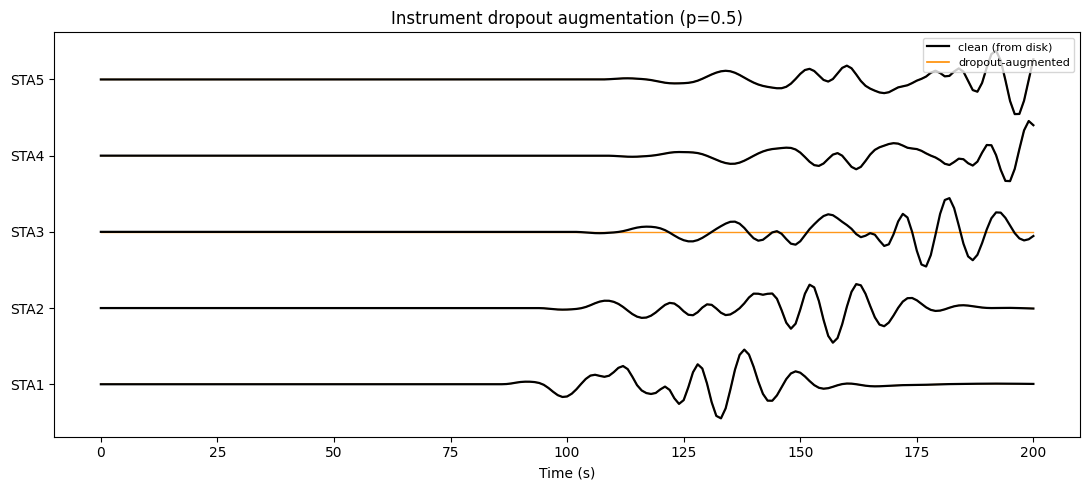

In [5]:
np.random.seed(3)
drop_chain = PostProcessingChain([InstrumentDropoutEffect()])
D_drop = apply_chain_to_array(drop_chain, D_clean, receivers, COMPONENTS,
                              {"instrument_dropout": 0.5})  # ~half the stations dropped

dropped = [name for i, name in enumerate(station_names)
           if np.all(D_drop[i, Z] == 0.0)]
print("Dropped stations this realisation:", dropped or "none")

plot_overlay(D_clean, D_drop, "Instrument dropout augmentation (p=0.5)",
             aug_label="dropout-augmented", aug_color="darkorange")
plt.tight_layout(); plt.show()

### 3c. Time shift

`TimeShiftErrorEffect` shifts each station's traces by the sum of two terms:

- a **common offset**, drawn once per call from `uniform(-uniform_offset, +uniform_offset)` and
  applied to **every** station (a velocity or source-time bias shared by all paths);
- an independent **per-station Gaussian** shift `N(0, gaussian_sigma)`.

The scalar `time_shift_error` switches the effect on or off (`0.0` leaves the traces unchanged).
Below, the two terms are shown separately.

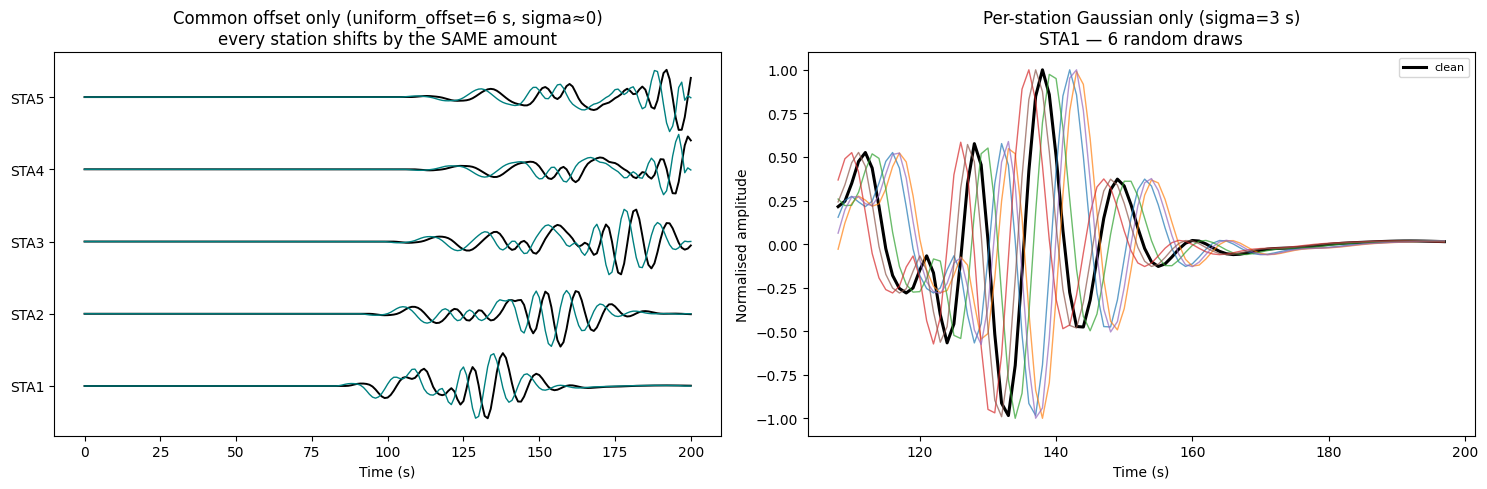

In [6]:
near = 0  # nearest station; zoom on its waveform
# Window around the main arrival for a clear view of the shift.
peak = int(np.argmax(np.abs(D_clean[near, Z])))
lo, hi = max(0, peak - 30), min(trace_len, peak + 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (i) Common offset ONLY: uniform_offset>0, sigma~0 → ALL stations shift identically.
np.random.seed(5)
ts_common = TimeShiftErrorEffect(sampling_rate=SAMPLING_RATE, uniform_offset=6.0, gaussian_sigma=1e-9)
D_common = apply_chain_to_array(PostProcessingChain([ts_common]), D_clean, receivers,
                                COMPONENTS, {"time_shift_error": 1.0})
for i, name in enumerate(station_names):
    c, a = D_clean[i, Z], D_common[i, Z]
    norm = np.max(np.abs(c)) or 1.0
    axes[0].plot(t_axis, c / norm + i * 2.2, "k-", lw=1.4)
    axes[0].plot(t_axis, a / norm + i * 2.2, color="teal", lw=1.0)
axes[0].set_title("Common offset only (uniform_offset=6 s, sigma≈0)\nevery station shifts by the SAME amount")
axes[0].set_yticks([i * 2.2 for i in range(n_stations)]); axes[0].set_yticklabels(station_names)
axes[0].set_xlabel("Time (s)")

# (ii) Per-station Gaussian ONLY: uniform_offset=0, sigma>0 → independent shifts.
ts_gauss = TimeShiftErrorEffect(sampling_rate=SAMPLING_RATE, uniform_offset=0.0, gaussian_sigma=3.0)
axes[1].plot(t_axis[lo:hi], D_clean[near, Z][lo:hi] / (np.max(np.abs(D_clean[near, Z])) or 1.0),
             "k-", lw=2.2, label="clean")
for s in range(6):  # several Gaussian draws at the nearest station
    np.random.seed(10 + s)
    Ds = apply_chain_to_array(PostProcessingChain([ts_gauss]), D_clean, receivers,
                              COMPONENTS, {"time_shift_error": 1.0})
    tr = Ds[near, Z][lo:hi] / (np.max(np.abs(Ds[near, Z])) or 1.0)
    axes[1].plot(t_axis[lo:hi], tr, lw=1.0, alpha=0.7)
axes[1].set_title(f"Per-station Gaussian only (sigma=3 s)\n{station_names[near]} — 6 random draws")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Normalised amplitude"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### 3d. Scattering coda — Stähler & Sigloch (2016), `stahler` mode

`ScatteringCodaEffect` convolves each selected station's traces with a compact, random-phase
FIR filter (the modelling-error transfer function), adding oscillatory coda that trails the
direct arrival.

The coda **strength `alpha` is sampled independently per station** from
`uniform(alpha_range)`, default `alpha_range = (0.0, 1.0)` (set with the `alpha_range`
config key). All components of a station share that station's `alpha`. `scattering_coda`
is the per-station perturbation probability; here it is 1.0, so every station is perturbed,
in `stahler` mode.

Because `alpha` varies from station to station, the coda strength (and hence the energy
redistribution) differs across the array within a single realisation.

  STA1: energy ratio (coda/clean) = 0.51
  STA2: energy ratio (coda/clean) = 0.82
  STA3: energy ratio (coda/clean) = 0.54
  STA4: energy ratio (coda/clean) = 0.55
  STA5: energy ratio (coda/clean) = 0.36


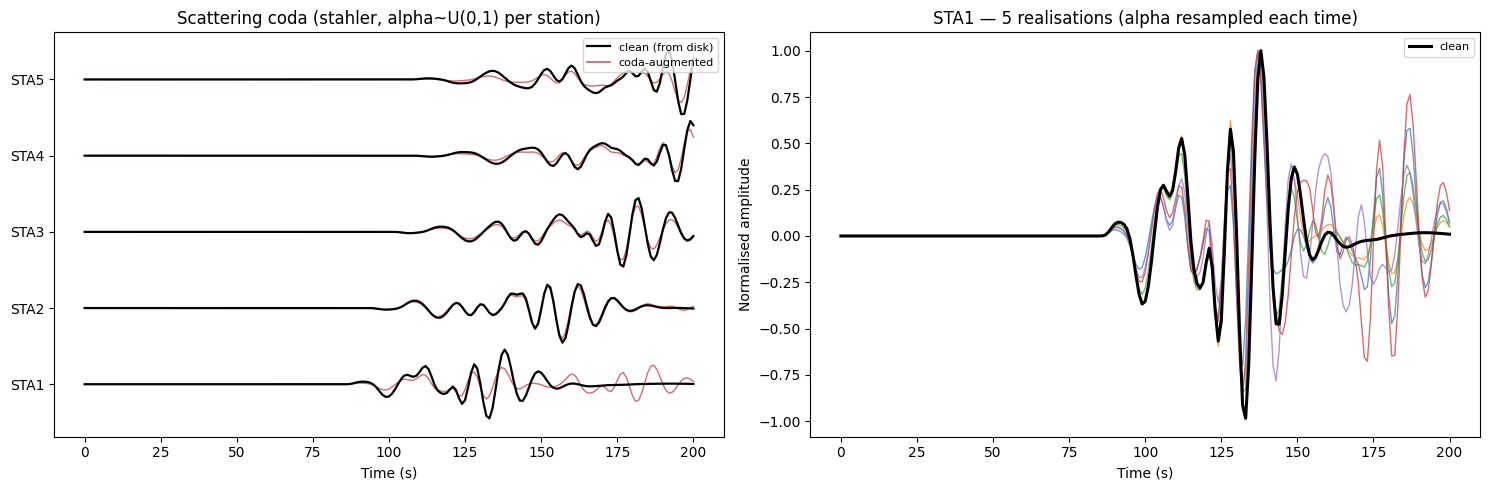

In [7]:
np.random.seed(8)
# Default per-station alpha sampling is uniform(0, 1); pass alpha_range to change it,
# e.g. ScatteringCodaEffect(alpha_range=(0.3, 0.8), mode="stahler").
coda_effect = ScatteringCodaEffect(alpha_range=(0.0, 1.0), mode="stahler")
coda_chain = PostProcessingChain([coda_effect])
D_coda = apply_chain_to_array(coda_chain, D_clean, receivers, COMPONENTS,
                              {"scattering_coda": 1.0})

# alpha is drawn per station, so the per-station energy redistribution varies across the array.
for i, name in enumerate(station_names):
    e_clean = np.sum(D_clean[i, Z] ** 2) or 1.0
    e_coda  = np.sum(D_coda[i, Z] ** 2)
    print(f"  {name}: energy ratio (coda/clean) = {e_coda / e_clean:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: clean vs coda-augmented record section (per-station alpha ~ U(0,1))
plot_overlay(D_clean, D_coda, "Scattering coda (stahler, alpha~U(0,1) per station)",
             aug_label="coda-augmented", aug_color="indianred", ax=ax1)

# Panel B: nearest station over several realisations — variable coda strength
ax2.plot(t_axis, D_clean[near, Z] / (np.max(np.abs(D_clean[near, Z])) or 1.0),
         "k-", lw=2.2, label="clean", zorder=5)
for s in range(5):
    np.random.seed(20 + s)
    Ds = apply_chain_to_array(coda_chain, D_clean, receivers, COMPONENTS, {"scattering_coda": 1.0})
    ax2.plot(t_axis, Ds[near, Z] / (np.max(np.abs(Ds[near, Z])) or 1.0),
             lw=1.0, alpha=0.7)
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Normalised amplitude")
ax2.set_title(f"{station_names[near]} — 5 realisations (alpha resampled each time)")
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 4. Build the chain straight from config (`build_augmentation_chain`)

In the pipeline the chain is built from `parameters.nuisance` + `parameters.nuisance_stage`
(parsed from the YAML `stage:` key). Only nuisances staged `training_augmentation` are folded
in here; `simulation`-staged ones are baked into the sims and excluded. This is the function
`scripts/train_NPE.py` calls.

The **activation scalar for each effect is its configured fiducial value** — so
`instrument_dropout: [0.3]` augments with a 30% per-station dropout probability (not 100%).

Augmented effects: ['InstrumentDropoutEffect', 'TimeShiftErrorEffect']
Activation params : {'instrument_dropout': 0.3, 'time_shift_error': 1.0}
  → instrument_dropout uses its fiducial 0.3 (30% per-station), not a hardcoded 1.0
  → amplitude_error is staged 'simulation' → correctly excluded from augmentation


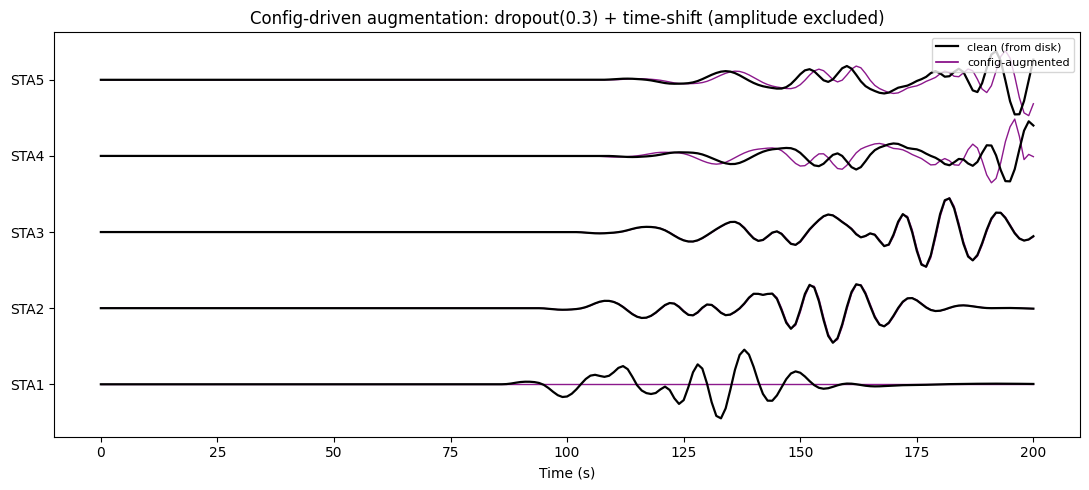

In [8]:
# Mimic the parsed config objects. `nuisance` maps key -> fiducial values, exactly
# as ModelParameters.nuisance does after SBI_Configuration.parse_parameters.
nuisance = {
    "amplitude_error": [0.5],         # per-station prob (excluded below: staged 'simulation')
    "instrument_dropout": [0.3],      # 30% per-station dropout probability
    "time_shift_error": [1.0],        # on/off switch
}
nuisance_stage = {
    "amplitude_error":   "simulation",            # baked into sims → NOT augmented
    "instrument_dropout": "training_augmentation",
    "time_shift_error":  "training_augmentation",
}
nuisance_effect_config = {
    "time_shift_error": {"uniform_offset": 2.0, "gaussian_sigma": 2.0},
}

aug_chain, aug_params = build_augmentation_chain(
    nuisance, nuisance_stage, nuisance_effect_config, sampling_rate=SAMPLING_RATE,
)
print("Augmented effects:", [type(e).__name__ for e in aug_chain.effects])
print("Activation params :", aug_params)
print("  → instrument_dropout uses its fiducial 0.3 (30% per-station), not a hardcoded 1.0")
print("  → amplitude_error is staged 'simulation' → correctly excluded from augmentation")

np.random.seed(7)
D_cfg = apply_chain_to_array(aug_chain, D_clean, receivers, COMPONENTS, aug_params)
plot_overlay(D_clean, D_cfg,
             "Config-driven augmentation: dropout(0.3) + time-shift (amplitude excluded)",
             aug_label="config-augmented", aug_color="purple")
plt.tight_layout(); plt.show()

## 5. End-to-end via `TorchSimulationDataset`

Finally, the real training path: a `TorchSimulationDataset` reads the saved sim from disk and
augments it inside `__getitem__`, **before noise is added**. Here we stub the noise sampler to
zero so the returned `x` equals the augmented `D` and the effect is visible in isolation. We
also confirm augmentation is reproducible under a fixed seed.

x shape: (5, 3, 201)
Reproducible under fixed seed: True


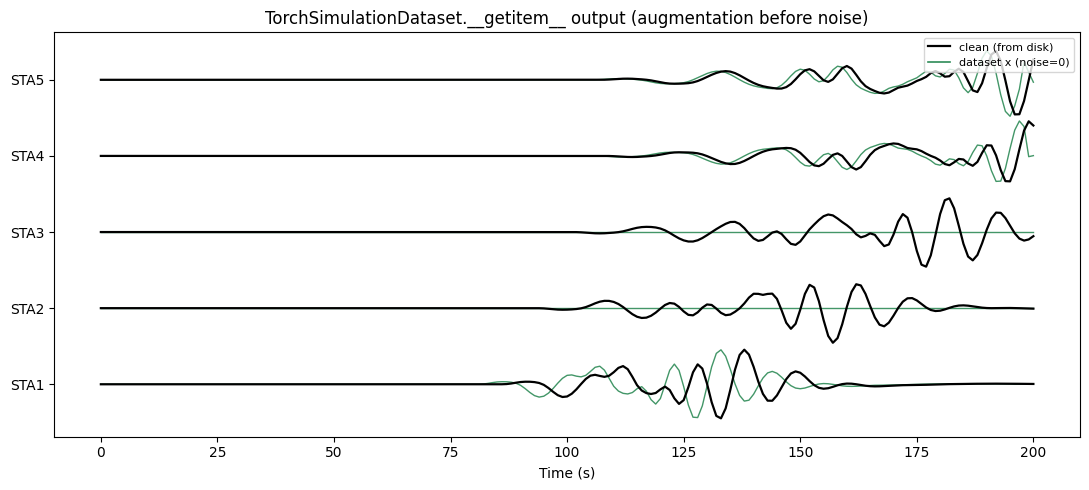

In [9]:
import torch
from seismo_sbi.sbi.compression.ML.dataloading import TorchSimulationDataset

ds = TorchSimulationDataset.__new__(TorchSimulationDataset)
ds.data_loader = data_loader
ds.parameter_name_map = {}
ds.conditioning_param_map = {}
ds.data_scaler = None
ds.return_tensors = True
ds.torch_dtype = torch.float32
ds.augmentation_chain = aug_chain
ds.augmentation_nuisance_params = aug_params
ds.paths = [sim_path]
n_used = sum(len(r.components) for r in receivers.iterate())
ds.synthetic_noise_model_sampler = lambda: np.zeros((n_used, trace_len))  # zero noise → x == augmented D

np.random.seed(42)
_, x1 = ds[0]
np.random.seed(42)
_, x2 = ds[0]
print("x shape:", tuple(x1.shape))
print("Reproducible under fixed seed:", np.allclose(x1.numpy(), x2.numpy()))

np.random.seed(123)
_, x = ds[0]
plot_overlay(D_clean, x.numpy(),
             "TorchSimulationDataset.__getitem__ output (augmentation before noise)",
             aug_label="dataset x (noise=0)", aug_color="seagreen")
plt.tight_layout(); plt.show()

---
## Summary

| Stage | Where it happens | Effects |
|---|---|---|
| `stage: simulation` | applied to each simulation by `Simulator.run_simulation` (used by the theory-error ensemble) | any Category-2 effect |
| `stage: training_augmentation` | applied to the clean `D` per batch in `TorchSimulationDataset` via `apply_chain_to_array` | amplitude / dropout / time-shift / coda |

Both routes use the same `SeismogramEffect` classes, so an effect behaves identically at
simulation time and at training time. `build_augmentation_chain` activates each effect at its
**configured fiducial probability or switch**, so e.g. `instrument_dropout: [0.3]` means a 30 %
per-station dropout, not all stations. Augmentation trains the network on a small fixed set of
clean, noise-free simulations while exposing it to the full nuisance distribution.